In [5]:
from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [6]:
import os

ROOT = "/content/gdrive/MyDrive/MRI Images"

print(os.listdir(ROOT))

['Training', 'Testing']


In [7]:
train_path = ROOT + "/Training"
test_path = ROOT + "/Testing"


print("Training folders:")
print(os.listdir(train_path))


print("\nTesting folders:")
print(os.listdir(test_path))

Training folders:
['notumor', 'pituitary', 'meningioma', 'glioma']

Testing folders:
['pituitary', 'notumor', 'glioma', 'meningioma']


In [8]:
for folder in os.listdir(train_path):

    path = os.path.join(train_path,folder)

    print(folder, ":", len(os.listdir(path)))

notumor : 1416
pituitary : 1400
meningioma : 1400
glioma : 1412


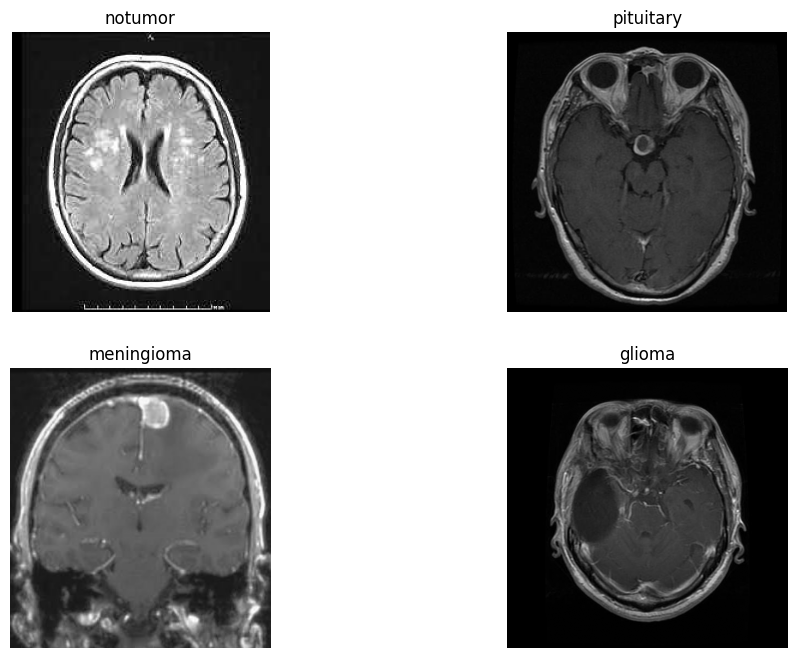

In [9]:
import matplotlib.pyplot as plt
import random
import os


plt.figure(figsize=(12,8))


classes = os.listdir(train_path)


for i,cls in enumerate(classes):

    folder = os.path.join(train_path,cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder,img_name)


    img = plt.imread(img_path)


    plt.subplot(2,2,i+1)
    plt.imshow(img,cmap="gray")
    plt.title(cls)
    plt.axis("off")


plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


In [11]:
#Image Transform
transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.ToTensor()

])


print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [12]:
#Dataset Load
train_dataset = datasets.ImageFolder(
    train_path,
    transform=transform
)


test_dataset = datasets.ImageFolder(
    test_path,
    transform=transform
)


print("Train images:",len(train_dataset))
print("Test images:",len(test_dataset))

Train images: 5628
Test images: 1608


In [13]:
#Classes check
print("Classes:")
print(train_dataset.classes)


print("\nClass mapping:")
print(train_dataset.class_to_idx)

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [14]:
#DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print("Train batches:",len(train_loader))
print("Test batches:",len(test_loader))

Train batches: 176
Test batches: 51


In [15]:
#Batch image check
images,labels = next(iter(train_loader))


print("Image batch shape:")
print(images.shape)


print("Label shape:")
print(labels.shape)


print("First 10 labels:")
print(labels[:10])

Image batch shape:
torch.Size([32, 3, 224, 224])
Label shape:
torch.Size([32])
First 10 labels:
tensor([1, 0, 1, 1, 2, 1, 1, 1, 2, 2])


In [16]:
# CNN Model
class CNN(nn.Module):

    def __init__(self):
        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(32*56*56,128),

            nn.ReLU(),

            nn.Linear(128,4)

        )


    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x



model=CNN().to(device)


print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [17]:
# odel test forward pass
sample = images.to(device)


output = model(sample)


print("Output shape:")
print(output.shape)

Output shape:
torch.Size([32, 4])


In [18]:
# Loss + Optimizer
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


print("Loss and optimizer ready")

Loss and optimizer ready


In [19]:
# Training Loop
epochs = 5


for epoch in range(epochs):

    model.train()

    total_loss = 0


    for images,labels in train_loader:


        images = images.to(device)
        labels = labels.to(device)


        output = model(images)


        loss = criterion(output,labels)


        optimizer.zero_grad()


        loss.backward()


        optimizer.step()


        total_loss += loss.item()



    avg_loss = total_loss/len(train_loader)


    print(
        f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}"
    )

Epoch 1/5 Loss: 0.7295
Epoch 2/5 Loss: 0.3850
Epoch 3/5 Loss: 0.2548
Epoch 4/5 Loss: 0.1569
Epoch 5/5 Loss: 0.0886


In [20]:
#Accuracy Test
model.eval()


correct = 0
total = 0


with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)


        output = model(images)


        prediction = torch.argmax(output,1)


        correct += (prediction==labels).sum().item()

        total += labels.size(0)



accuracy = correct/total*100


print("Test Accuracy:",accuracy,"%")

Test Accuracy: 86.69154228855722 %


In [21]:
train_losses = []
val_losses = []

In [23]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[306  44  50   8]
 [ 50 320  20  10]
 [  1   1 398   0]
 [ 14  21   1 364]]


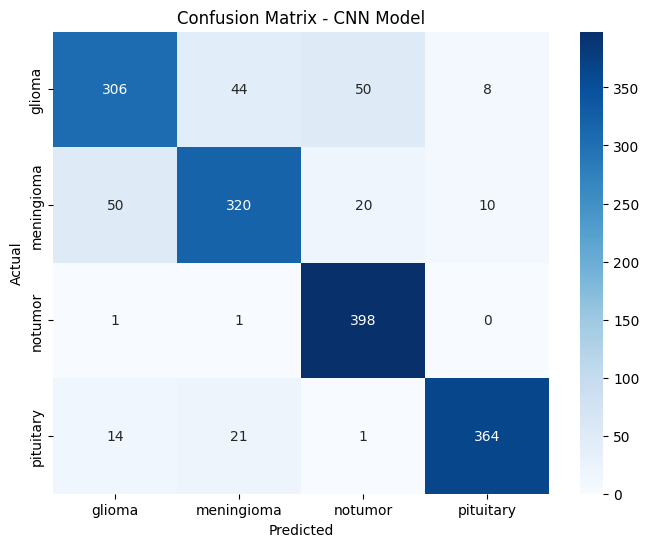

In [24]:
class_names = train_dataset.classes

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Model")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.82      0.75      0.79       408
  meningioma       0.83      0.80      0.81       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.95      0.91      0.93       400

    accuracy                           0.86      1608
   macro avg       0.86      0.86      0.86      1608
weighted avg       0.86      0.86      0.86      1608



In [26]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': train_dataset.classes
}, "brain_tumor_cnn.pth")

print("Model saved successfully!")

Model saved successfully!


In [27]:
from PIL import Image
import random
import os

In [28]:
class_name = random.choice(os.listdir(test_path))
img_name = random.choice(os.listdir(os.path.join(test_path, class_name)))

img_path = os.path.join(test_path, class_name, img_name)

print("Actual Class:", class_name)

Actual Class: glioma


In [29]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

image = Image.open(img_path).convert("RGB")
img_tensor = transform(image).unsqueeze(0).to(device)

In [30]:
model.eval()

with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output, 1).item()

print("Predicted Class:", train_dataset.classes[pred])

Predicted Class: glioma


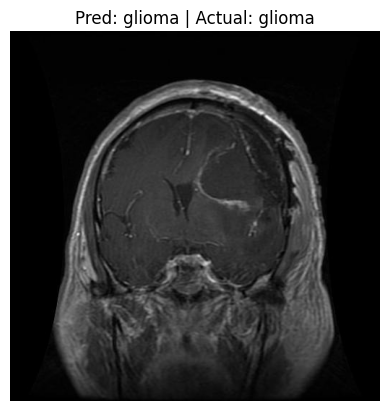

In [31]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f"Pred: {train_dataset.classes[pred]} | Actual: {class_name}")
plt.axis("off")
plt.show()